# 🧠 VR Soccer Multi-Epoch EEG Analysis

## Analysis Pipeline for Pre-Processed EEG Epochs

This notebook analyzes the existing VR Soccer Development EEG data with:
- Multiple conditions (OnField, VR, different players)
- Pre-extracted epochs in EDF format
- Already cleaned epochs (ICA artifact removal completed)
- Multi-epoch topographic comparisons
- Temporal dynamics analysis

---

## 1. Setup and Data Discovery

In [1]:
# Imports
import os
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# MNE settings
mne.set_log_level('WARNING')
plt.style.use('seaborn-v0_8-whitegrid')

# Get username for OneDrive path
username = os.getlogin()
BASE_DIR = Path(rf"C:\Users\{username}\OneDrive - Clemson University\Documents\GitHub\VR-Soccer-Development-Data_Processing\epochs_as_edf_all")

print(f"Base directory: {BASE_DIR}")
print(f"Directory exists: {BASE_DIR.exists()}")

# Discover all conditions
conditions = [d for d in BASE_DIR.iterdir() if d.is_dir()]
print(f"\nFound {len(conditions)} experimental conditions:")
for condition in conditions[:10]:  # Show first 10
    print(f"  - {condition.name}")

Base directory: C:\Users\2003d\OneDrive - Clemson University\Documents\GitHub\VR-Soccer-Development-Data_Processing\epochs_as_edf_all
Directory exists: True

Found 47 experimental conditions:
  - Men_OnField_James_OnField_040425_raw
  - Men_OnField_James_Onfield_3_raw
  - Men_OnField_James_PlayerD_onField_040125_raw
  - Men_OnField_Mason_OnField_040425_raw
  - Men_OnField_Mason_Onfield_3_raw
  - Men_OnField_mason_onfield_final_raw
  - Men_OnField_Mason_PlayerC_onfield_040125_raw
  - Men_OnField_On field-b_raw
  - Men_OnField_On field-c_raw
  - Men_OnField_Player3-Mason-onfield-trial 5_raw


In [2]:
# Analyze data structure for a specific condition
def analyze_condition_structure(condition_path):
    """Analyze the structure of epochs in a condition folder."""
    condition_path = Path(condition_path)
    
    # Find raw epochs
    raw_epochs = list(condition_path.glob("*.edf"))
    
    # Find cleaned epochs
    cleaned_dir = condition_path / "cleaned"
    cleaned_epochs = []
    if cleaned_dir.exists():
        cleaned_epochs = list(cleaned_dir.glob("*_cleaned.edf"))
    
    print(f"\nCondition: {condition_path.name}")
    print(f"  Raw epochs: {len(raw_epochs)}")
    print(f"  Cleaned epochs: {len(cleaned_epochs)}")
    
    if raw_epochs:
        print(f"\n  Sample raw files:")
        for epoch in raw_epochs[:3]:
            print(f"    - {epoch.name}")
    
    if cleaned_epochs:
        print(f"\n  Sample cleaned files:")
        for epoch in cleaned_epochs[:3]:
            print(f"    - {epoch.name}")
    
    return raw_epochs, cleaned_epochs

# Example: Analyze James_Onfield_3 condition
test_condition = BASE_DIR / "Men_OnField_James_Onfield_3_raw"
if test_condition.exists():
    raw_epochs, cleaned_epochs = analyze_condition_structure(test_condition)
else:
    # Try to find any condition with epochs
    for condition in conditions:
        if any(condition.glob("*.edf")):
            raw_epochs, cleaned_epochs = analyze_condition_structure(condition)
            break


Condition: Men_OnField_James_Onfield_3_raw
  Raw epochs: 14
  Cleaned epochs: 14

  Sample raw files:
    - James_Onfield_3_raw_epoch_001.edf
    - James_Onfield_3_raw_epoch_002.edf
    - James_Onfield_3_raw_epoch_003.edf

  Sample cleaned files:
    - James_Onfield_3_raw_epoch_001_cleaned.edf
    - James_Onfield_3_raw_epoch_002_cleaned.edf
    - James_Onfield_3_raw_epoch_003_cleaned.edf


## 2. Load and Inspect Epochs

In [3]:
def load_epochs_from_condition(condition_path, use_cleaned=True, max_epochs=None):
    """
    Load multiple epochs from a condition folder.
    
    Parameters:
    -----------
    condition_path : Path
        Path to condition folder
    use_cleaned : bool
        If True, load cleaned epochs; else load raw epochs
    max_epochs : int
        Maximum number of epochs to load
    """
    condition_path = Path(condition_path)
    
    if use_cleaned:
        epochs_dir = condition_path / "cleaned"
        pattern = "*_cleaned.edf"
    else:
        epochs_dir = condition_path
        pattern = "*epoch*.edf"
    
    # Find epoch files
    epoch_files = sorted(epochs_dir.glob(pattern))
    
    if max_epochs:
        epoch_files = epoch_files[:max_epochs]
    
    print(f"Loading {len(epoch_files)} epochs from {epochs_dir.name}...")
    
    loaded_epochs = {}
    
    for i, epoch_file in enumerate(epoch_files, 1):
        try:
            raw = mne.io.read_raw_edf(str(epoch_file), preload=True, verbose=False)
            epoch_name = f"Epoch {i:02d}"
            loaded_epochs[epoch_name] = raw
            print(f"  ✓ Loaded {epoch_name}: {epoch_file.name}")
        except Exception as e:
            print(f"  ✗ Failed to load {epoch_file.name}: {e}")
    
    return loaded_epochs

# Load cleaned epochs from James_Onfield_3
condition_path = BASE_DIR / "Men_OnField_James_Onfield_3_raw"
epochs_data = load_epochs_from_condition(condition_path, use_cleaned=True, max_epochs=6)

# If no cleaned epochs, try raw epochs
if not epochs_data:
    print("\nNo cleaned epochs found, loading raw epochs...")
    epochs_data = load_epochs_from_condition(condition_path, use_cleaned=False, max_epochs=6)

Loading 6 epochs from cleaned...
  ✓ Loaded Epoch 01: James_Onfield_3_raw_epoch_001_cleaned.edf
  ✓ Loaded Epoch 02: James_Onfield_3_raw_epoch_002_cleaned.edf
  ✓ Loaded Epoch 03: James_Onfield_3_raw_epoch_003_cleaned.edf
  ✓ Loaded Epoch 04: James_Onfield_3_raw_epoch_004_cleaned.edf
  ✓ Loaded Epoch 05: James_Onfield_3_raw_epoch_005_cleaned.edf
  ✓ Loaded Epoch 06: James_Onfield_3_raw_epoch_006_cleaned.edf


In [4]:
# Inspect the first epoch
if epochs_data:
    first_epoch = list(epochs_data.values())[0]
    
    print("\nFirst Epoch Information:")
    print(f"  Channels: {len(first_epoch.ch_names)}")
    print(f"  Sampling rate: {first_epoch.info['sfreq']} Hz")
    print(f"  Duration: {first_epoch.n_times / first_epoch.info['sfreq']:.2f} seconds")
    
    # Check for EEG channels
    eeg_channels = mne.pick_types(first_epoch.info, eeg=True)
    print(f"  EEG channels: {len(eeg_channels)}")
    
    # Show channel names
    print(f"\n  Channel names (first 10):")
    for ch in first_epoch.ch_names[:10]:
        print(f"    - {ch}")


First Epoch Information:
  Channels: 30
  Sampling rate: 300.0 Hz
  Duration: 5.00 seconds
  EEG channels: 29

  Channel names (first 10):
    - P3
    - C3
    - F3
    - Fz
    - F4
    - C4
    - P4
    - Cz
    - CM
    - A1


## 3. Fix Channel Types and Montage

In [5]:
def fix_channel_montage(raw):
    """
    Fix channel types and apply standard montage.
    """
    # Get standard montage
    montage = mne.channels.make_standard_montage('standard_1020')
    montage_names = set(montage.ch_names)
    
    # Identify EEG channels that match montage
    eeg_channels = [ch for ch in raw.ch_names if ch in montage_names]
    
    if eeg_channels:
        # Set channel types
        raw.set_channel_types({ch: 'eeg' for ch in eeg_channels})
        
        # Set other channels to misc
        other_channels = [ch for ch in raw.ch_names if ch not in eeg_channels]
        if other_channels:
            raw.set_channel_types({ch: 'misc' for ch in other_channels})
        
        # Apply montage
        raw.set_montage(montage, on_missing='ignore')
        
        print(f"  ✓ Montage applied: {len(eeg_channels)} EEG channels with positions")
    else:
        print("  ⚠ No standard EEG channels found")
    
    return raw

# Fix montage for all loaded epochs
print("Fixing channel montages...")
for epoch_name, raw in epochs_data.items():
    print(f"\n{epoch_name}:")
    epochs_data[epoch_name] = fix_channel_montage(raw)

Fixing channel montages...

Epoch 01:
  ✓ Montage applied: 21 EEG channels with positions

Epoch 02:
  ✓ Montage applied: 21 EEG channels with positions

Epoch 03:
  ✓ Montage applied: 21 EEG channels with positions

Epoch 04:
  ✓ Montage applied: 21 EEG channels with positions

Epoch 05:
  ✓ Montage applied: 21 EEG channels with positions

Epoch 06:
  ✓ Montage applied: 21 EEG channels with positions


## 4. Compute Band Powers

In [6]:
def compute_band_topography(raw, band='alpha'):
    """
    Compute topographic distribution of band power.
    """
    bands = {
        'delta': (0.5, 4),
        'theta': (4, 8),
        'alpha': (8, 13),
        'beta': (13, 30),
        'gamma': (30, 45)
    }
    
    fmin, fmax = bands.get(band.lower(), (8, 13))
    
    # Pick EEG channels
    raw_eeg = raw.copy().pick('eeg')
    
    if len(raw_eeg.ch_names) == 0:
        print(f"  ⚠ No EEG channels found for {band} band")
        return None
    
    # Compute PSD
    n_fft = min(256, raw_eeg.n_times // 4)
    spectrum = raw_eeg.compute_psd(
        method='welch',
        fmin=fmin,
        fmax=fmax,
        n_fft=n_fft,
        n_overlap=n_fft // 2,
        verbose=False
    )
    
    # Get power for each channel
    psds = spectrum.get_data()
    band_power = psds.mean(axis=1)
    
    return band_power

# Compute alpha power for all epochs
alpha_powers = {}
for epoch_name, raw in epochs_data.items():
    power = compute_band_topography(raw, 'alpha')
    if power is not None:
        alpha_powers[epoch_name] = power
        print(f"{epoch_name}: Mean alpha = {power.mean():.2e}")

Epoch 01: Mean alpha = 2.16e-07
Epoch 02: Mean alpha = 2.03e-07
Epoch 03: Mean alpha = 2.13e-07
Epoch 04: Mean alpha = 2.06e-07
Epoch 05: Mean alpha = 2.00e-07
Epoch 06: Mean alpha = 2.10e-07


## 5. Create Multi-Epoch Topographic Maps

✓ Saved to alpha_band_comparison.png


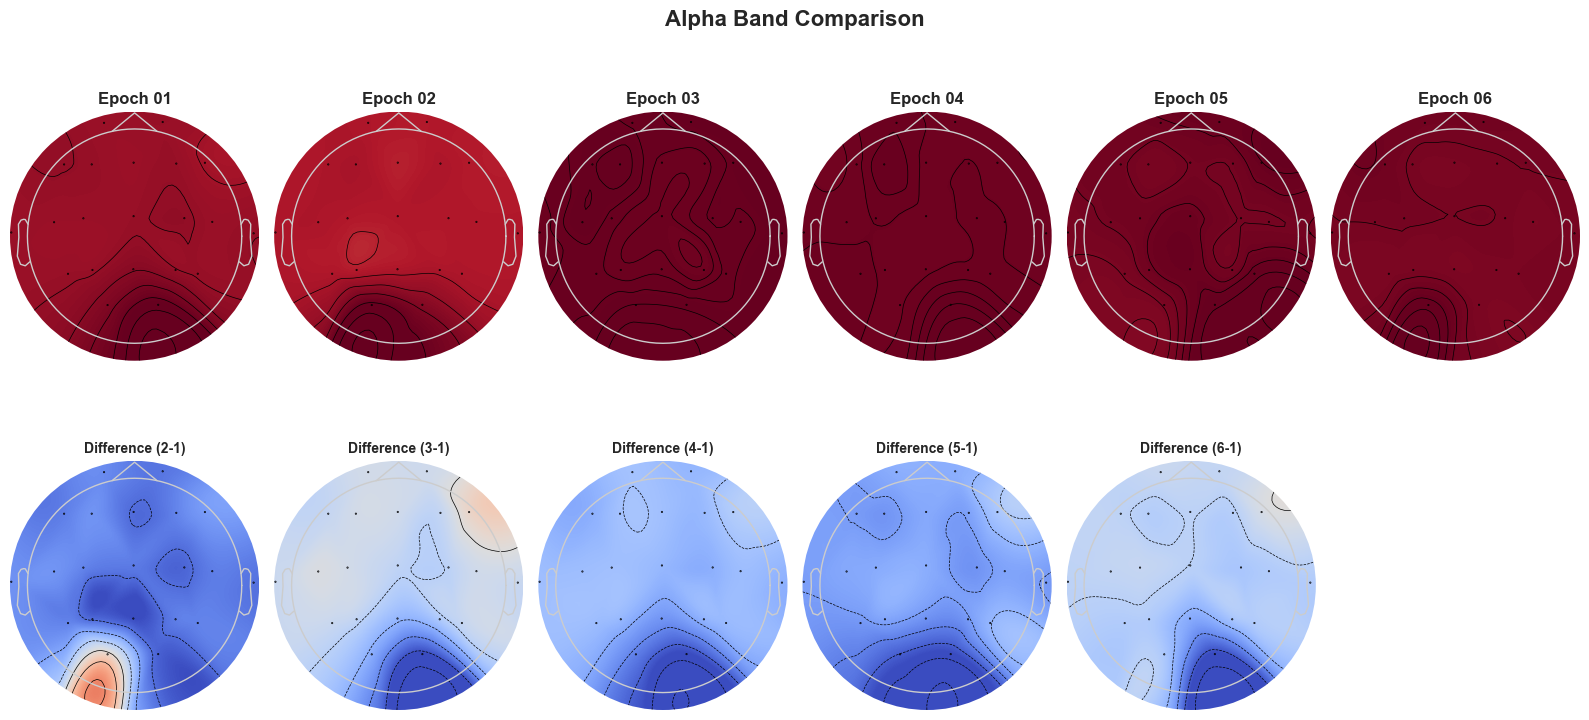

In [7]:
def create_multi_epoch_topomaps(epochs_data, band='alpha', save_path=None):
    """
    Create topographic maps for multiple epochs with difference maps.
    Similar to your original image.
    """
    n_epochs = len(epochs_data)
    
    # Create figure layout
    fig = plt.figure(figsize=(16, 8))
    
    # Top row: Individual epochs
    # Bottom row: Difference maps
    n_cols = min(n_epochs, 6)
    n_diff = min(n_epochs - 1, 5)
    
    band_powers = []
    
    # Plot individual epochs
    for i, (epoch_name, raw) in enumerate(epochs_data.items()):
        if i >= 6:
            break
            
        ax = plt.subplot(2, n_cols, i + 1)
        
        # Compute band power
        band_power = compute_band_topography(raw, band)
        
        if band_power is not None:
            band_powers.append(band_power)
            
            # Get EEG info for plotting
            raw_eeg = raw.copy().pick('eeg')
            
            # Plot topomap
            im = mne.viz.plot_topomap(
                band_power,
                raw_eeg.info,
                axes=ax,
                show=False,
                cmap='RdBu_r',
                contours=6,
                sensors=True
            )
            
            ax.set_title(epoch_name, fontsize=12, fontweight='bold')
    
    # Plot difference maps
    if len(band_powers) > 1:
        # Get reference epoch info
        ref_raw = list(epochs_data.values())[0].copy().pick('eeg')
        
        for i in range(min(n_diff, 5)):
            ax = plt.subplot(2, n_cols, n_cols + i + 1)
            
            # Compute difference
            diff = band_powers[i + 1] - band_powers[0]
            
            # Plot difference topomap
            im = mne.viz.plot_topomap(
                diff,
                ref_raw.info,
                axes=ax,
                show=False,
                cmap='coolwarm',
                contours=6,
                sensors=True
            )
            
            ax.set_title(f'Difference ({i+2}-1)', fontsize=10, fontweight='bold')
    
    plt.suptitle(f'{band.capitalize()} Band Comparison', fontsize=16, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✓ Saved to {save_path}")
    
    plt.show()
    
    return fig, band_powers

# Create the topographic maps
if epochs_data:
    fig, band_powers = create_multi_epoch_topomaps(
        epochs_data, 
        band='alpha',
        save_path='alpha_band_comparison.png'
    )

## 6. Compute Metrics Across Epochs

In [8]:
def compute_epoch_metrics(epochs_data):
    """
    Compute various metrics for each epoch.
    """
    metrics = []
    
    bands = {
        'delta': (0.5, 4),
        'theta': (4, 8),
        'alpha': (8, 13),
        'beta': (13, 30),
        'gamma': (30, 45)
    }
    
    for epoch_name, raw in epochs_data.items():
        epoch_metrics = {'epoch': epoch_name}
        
        # Pick EEG channels
        raw_eeg = raw.copy().pick('eeg')
        
        if len(raw_eeg.ch_names) > 0:
            # Compute band powers
            for band_name, (fmin, fmax) in bands.items():
                try:
                    n_fft = min(256, raw_eeg.n_times // 4)
                    spectrum = raw_eeg.compute_psd(
                        method='welch',
                        fmin=fmin,
                        fmax=fmax,
                        n_fft=n_fft,
                        verbose=False
                    )
                    power = spectrum.get_data().mean()
                    epoch_metrics[band_name] = power
                except:
                    epoch_metrics[band_name] = np.nan
            
            # Compute indices
            if epoch_metrics.get('alpha') and epoch_metrics.get('theta'):
                epoch_metrics['theta_alpha_ratio'] = epoch_metrics['theta'] / epoch_metrics['alpha']
            
            if epoch_metrics.get('beta') and epoch_metrics.get('alpha'):
                epoch_metrics['beta_alpha_ratio'] = epoch_metrics['beta'] / epoch_metrics['alpha']
            
            if all(k in epoch_metrics for k in ['beta', 'alpha', 'theta']):
                epoch_metrics['engagement'] = epoch_metrics['beta'] / \
                                             (epoch_metrics['alpha'] + epoch_metrics['theta'])
        
        metrics.append(epoch_metrics)
    
    return pd.DataFrame(metrics)

# Compute metrics
metrics_df = compute_epoch_metrics(epochs_data)
print("\nEpoch Metrics:")
print(metrics_df.round(6))


Epoch Metrics:
      epoch     delta  theta  alpha  beta  gamma  theta_alpha_ratio  \
0  Epoch 01  0.000002    0.0    0.0   0.0    0.0           0.905119   
1  Epoch 02  0.000002    0.0    0.0   0.0    0.0           0.931978   
2  Epoch 03  0.000002    0.0    0.0   0.0    0.0           1.010074   
3  Epoch 04  0.000001    0.0    0.0   0.0    0.0           1.076865   
4  Epoch 05  0.000001    0.0    0.0   0.0    0.0           1.221326   
5  Epoch 06  0.000001    0.0    0.0   0.0    0.0           1.138679   

   beta_alpha_ratio  engagement  
0          0.920135    0.482980  
1          0.912696    0.472415  
2          0.944399    0.469833  
3          0.892202    0.429591  
4          0.900423    0.405354  
5          0.913386    0.427079  


## 7. Temporal Dynamics Analysis

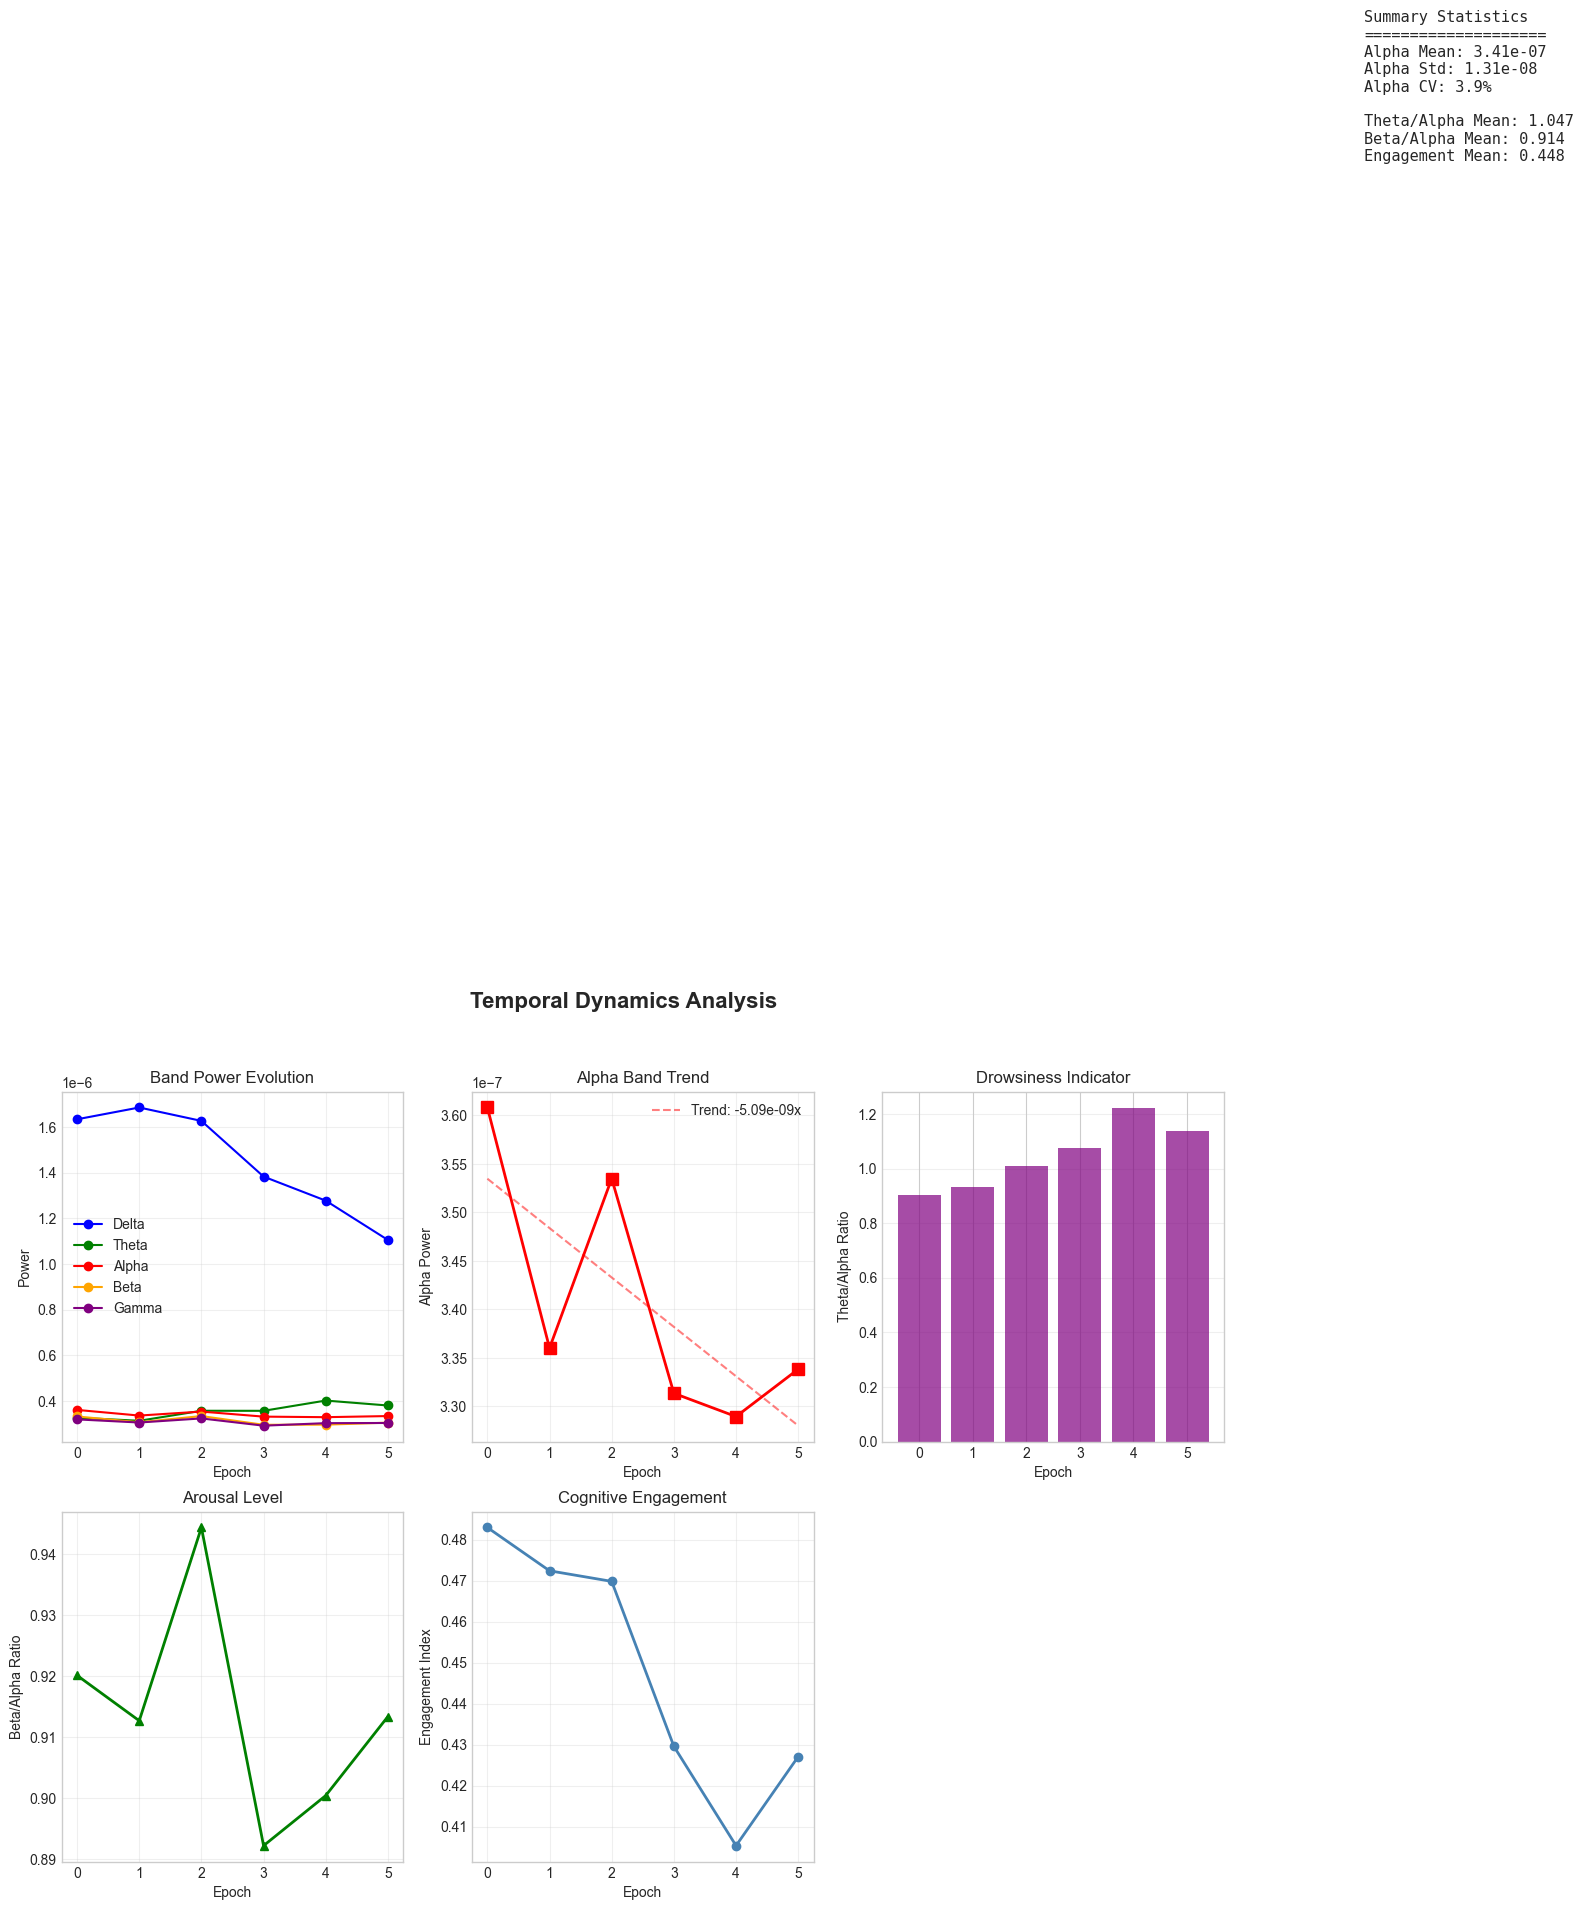

In [9]:
def plot_temporal_dynamics(metrics_df):
    """
    Plot temporal evolution of band powers and indices.
    """
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Plot band powers
    bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']
    colors = ['blue', 'green', 'red', 'orange', 'purple']
    
    for band, color in zip(bands, colors):
        if band in metrics_df.columns:
            axes[0, 0].plot(range(len(metrics_df)), metrics_df[band], 
                          marker='o', label=band.capitalize(), color=color)
    
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Power')
    axes[0, 0].set_title('Band Power Evolution')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Alpha power focus
    if 'alpha' in metrics_df.columns:
        axes[0, 1].plot(range(len(metrics_df)), metrics_df['alpha'], 
                       marker='s', color='red', linewidth=2, markersize=8)
        axes[0, 1].set_xlabel('Epoch')
        axes[0, 1].set_ylabel('Alpha Power')
        axes[0, 1].set_title('Alpha Band Trend')
        axes[0, 1].grid(True, alpha=0.3)
        
        # Add trend line
        x = np.array(range(len(metrics_df)))
        y = metrics_df['alpha'].values
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        axes[0, 1].plot(x, p(x), 'r--', alpha=0.5, label=f'Trend: {z[0]:.2e}x')
        axes[0, 1].legend()
    
    # Theta/Alpha ratio
    if 'theta_alpha_ratio' in metrics_df.columns:
        axes[0, 2].bar(range(len(metrics_df)), metrics_df['theta_alpha_ratio'],
                      color='purple', alpha=0.7)
        axes[0, 2].set_xlabel('Epoch')
        axes[0, 2].set_ylabel('Theta/Alpha Ratio')
        axes[0, 2].set_title('Drowsiness Indicator')
        axes[0, 2].grid(True, alpha=0.3, axis='y')
    
    # Beta/Alpha ratio
    if 'beta_alpha_ratio' in metrics_df.columns:
        axes[1, 0].plot(range(len(metrics_df)), metrics_df['beta_alpha_ratio'],
                       marker='^', color='green', linewidth=2)
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('Beta/Alpha Ratio')
        axes[1, 0].set_title('Arousal Level')
        axes[1, 0].grid(True, alpha=0.3)
    
    # Engagement index
    if 'engagement' in metrics_df.columns:
        axes[1, 1].plot(range(len(metrics_df)), metrics_df['engagement'],
                       marker='o', color='steelblue', linewidth=2)
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('Engagement Index')
        axes[1, 1].set_title('Cognitive Engagement')
        axes[1, 1].grid(True, alpha=0.3)
    
    # Summary statistics
    ax = axes[1, 2]
    ax.axis('tight')
    ax.axis('off')
    
    summary_text = "Summary Statistics\n" + "="*20 + "\n"
    
    if 'alpha' in metrics_df.columns:
        summary_text += f"Alpha Mean: {metrics_df['alpha'].mean():.2e}\n"
        summary_text += f"Alpha Std: {metrics_df['alpha'].std():.2e}\n"
        summary_text += f"Alpha CV: {metrics_df['alpha'].std()/metrics_df['alpha'].mean()*100:.1f}%\n\n"
    
    if 'theta_alpha_ratio' in metrics_df.columns:
        summary_text += f"Theta/Alpha Mean: {metrics_df['theta_alpha_ratio'].mean():.3f}\n"
    
    if 'beta_alpha_ratio' in metrics_df.columns:
        summary_text += f"Beta/Alpha Mean: {metrics_df['beta_alpha_ratio'].mean():.3f}\n"
    
    if 'engagement' in metrics_df.columns:
        summary_text += f"Engagement Mean: {metrics_df['engagement'].mean():.3f}\n"
    
    ax.text(0.1, 0.5, summary_text, fontsize=11, family='monospace',
            verticalalignment='center')
    
    plt.suptitle('Temporal Dynamics Analysis', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return fig

# Plot temporal dynamics
if not metrics_df.empty:
    fig = plot_temporal_dynamics(metrics_df)

## 8. Compare Multiple Conditions

Comparing 3 conditions...

Loading 3 epochs from cleaned...
  ✓ Loaded Epoch 01: James_Onfield_3_raw_epoch_001_cleaned.edf
  ✓ Loaded Epoch 02: James_Onfield_3_raw_epoch_002_cleaned.edf
  ✓ Loaded Epoch 03: James_Onfield_3_raw_epoch_003_cleaned.edf
  ✓ Montage applied: 21 EEG channels with positions
  ✓ Montage applied: 21 EEG channels with positions
  ✓ Montage applied: 21 EEG channels with positions
Loading 3 epochs from cleaned...
  ✓ Loaded Epoch 01: Mason_Onfield_3_raw_epoch_001_cleaned.edf
  ✓ Loaded Epoch 02: Mason_Onfield_3_raw_epoch_002_cleaned.edf
  ✓ Loaded Epoch 03: Mason_Onfield_3_raw_epoch_003_cleaned.edf
  ✓ Montage applied: 21 EEG channels with positions
  ✓ Montage applied: 21 EEG channels with positions
  ✓ Montage applied: 21 EEG channels with positions
Loading 3 epochs from cleaned...
  ✓ Loaded Epoch 01: Missei_VR_4_raw_epoch_001_cleaned.edf
  ✓ Loaded Epoch 02: Missei_VR_4_raw_epoch_002_cleaned.edf
  ✓ Loaded Epoch 03: Missei_VR_4_raw_epoch_003_cleaned.edf
  ✓ Mon

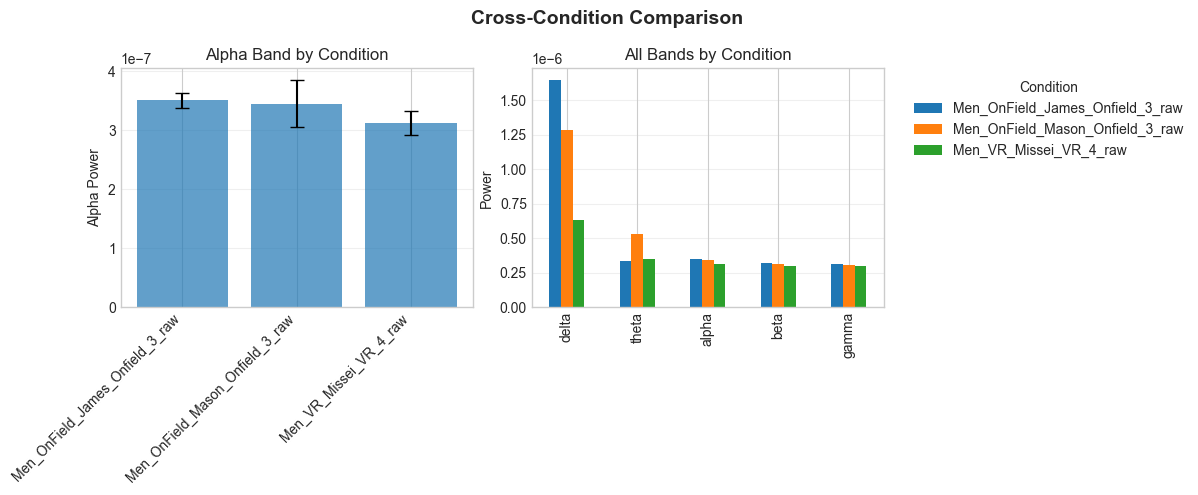

In [10]:
def compare_conditions(condition_paths, band='alpha', max_epochs=3):
    """
    Compare band power across different experimental conditions.
    """
    all_metrics = []
    
    for condition_path in condition_paths:
        condition_path = Path(condition_path)
        condition_name = condition_path.name
        
        # Load epochs
        epochs = load_epochs_from_condition(condition_path, use_cleaned=True, max_epochs=max_epochs)
        
        if not epochs:
            epochs = load_epochs_from_condition(condition_path, use_cleaned=False, max_epochs=max_epochs)
        
        # Fix montage
        for epoch_name, raw in epochs.items():
            epochs[epoch_name] = fix_channel_montage(raw)
        
        # Compute metrics
        metrics = compute_epoch_metrics(epochs)
        metrics['condition'] = condition_name
        all_metrics.append(metrics)
    
    # Combine all metrics
    combined_df = pd.concat(all_metrics, ignore_index=True)
    
    # Plot comparison
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Alpha power by condition
    if band in combined_df.columns:
        condition_means = combined_df.groupby('condition')[band].agg(['mean', 'std'])
        
        axes[0].bar(range(len(condition_means)), condition_means['mean'], 
                   yerr=condition_means['std'], capsize=5, alpha=0.7)
        axes[0].set_xticks(range(len(condition_means)))
        axes[0].set_xticklabels(condition_means.index, rotation=45, ha='right')
        axes[0].set_ylabel(f'{band.capitalize()} Power')
        axes[0].set_title(f'{band.capitalize()} Band by Condition')
        axes[0].grid(True, alpha=0.3, axis='y')
    
    # All bands comparison
    bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']
    valid_bands = [b for b in bands if b in combined_df.columns]
    
    if valid_bands:
        band_means = combined_df.groupby('condition')[valid_bands].mean()
        band_means.T.plot(kind='bar', ax=axes[1])
        axes[1].set_ylabel('Power')
        axes[1].set_title('All Bands by Condition')
        axes[1].legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left')
        axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.suptitle('Cross-Condition Comparison', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return combined_df

# Compare different conditions
conditions_to_compare = [
    BASE_DIR / "Men_OnField_James_Onfield_3_raw",
    BASE_DIR / "Men_OnField_Mason_Onfield_3_raw",
    BASE_DIR / "Men_VR_Missei_VR_4_raw"
]

# Filter to existing conditions
existing_conditions = [c for c in conditions_to_compare if c.exists()]

if len(existing_conditions) >= 2:
    print(f"Comparing {len(existing_conditions)} conditions...\n")
    comparison_df = compare_conditions(existing_conditions[:3], band='alpha', max_epochs=3)
else:
    print("Not enough conditions found for comparison")

## 9. Save Results

In [11]:
# Save metrics to CSV
if not metrics_df.empty:
    output_file = 'epoch_metrics.csv'
    metrics_df.to_csv(output_file, index=False)
    print(f"✓ Metrics saved to {output_file}")
    
    # Display summary
    print("\n" + "="*60)
    print("ANALYSIS SUMMARY")
    print("="*60)
    
    print(f"\nEpochs analyzed: {len(metrics_df)}")
    
    if 'alpha' in metrics_df.columns:
        print(f"\nAlpha Band:")
        print(f"  Mean: {metrics_df['alpha'].mean():.2e}")
        print(f"  Std: {metrics_df['alpha'].std():.2e}")
        print(f"  CV: {metrics_df['alpha'].std()/metrics_df['alpha'].mean()*100:.1f}%")
        
        # Trend analysis
        x = np.array(range(len(metrics_df)))
        y = metrics_df['alpha'].values
        slope = np.polyfit(x, y, 1)[0]
        
        if slope < -1e-7:
            trend = "Decreasing (suppression)"
        elif slope > 1e-7:
            trend = "Increasing (enhancement)"
        else:
            trend = "Stable"
        
        print(f"  Trend: {trend} (slope: {slope:.2e})")
    
    print("\n" + "="*60)

✓ Metrics saved to epoch_metrics.csv

ANALYSIS SUMMARY

Epochs analyzed: 6

Alpha Band:
  Mean: 3.41e-07
  Std: 1.31e-08
  CV: 3.9%
  Trend: Stable (slope: -5.09e-09)



## 10. Generate Report

In [12]:
def generate_html_report(metrics_df, condition_name, output_file='report.html'):
    """
    Generate an HTML report of the analysis.
    """
    html_content = f"""
<!DOCTYPE html>
<html>
<head>
    <title>EEG Analysis Report - {condition_name}</title>
    <style>
        body {{
            font-family: Arial, sans-serif;
            max-width: 1200px;
            margin: 0 auto;
            padding: 20px;
            background-color: #f5f5f5;
        }}
        h1 {{
            color: #333;
            border-bottom: 3px solid #4CAF50;
            padding-bottom: 10px;
        }}
        .metric-box {{
            background: white;
            padding: 15px;
            margin: 10px;
            border-radius: 8px;
            box-shadow: 0 2px 4px rgba(0,0,0,0.1);
            display: inline-block;
        }}
        .metric-value {{
            font-size: 2em;
            font-weight: bold;
            color: #4CAF50;
        }}
        table {{
            width: 100%;
            border-collapse: collapse;
            background: white;
            margin: 20px 0;
        }}
        th, td {{
            padding: 10px;
            text-align: left;
            border-bottom: 1px solid #ddd;
        }}
        th {{
            background-color: #4CAF50;
            color: white;
        }}
    </style>
</head>
<body>
    <h1>EEG Multi-Epoch Analysis Report</h1>
    <h2>Condition: {condition_name}</h2>
    <p>Analysis Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}</p>
    
    <h3>Summary Statistics</h3>
    <div class="metrics">
"""
    
    # Add summary metrics
    if 'alpha' in metrics_df.columns:
        html_content += f"""
        <div class="metric-box">
            <div>Alpha Power</div>
            <div class="metric-value">{metrics_df['alpha'].mean():.2e}</div>
        </div>
"""
    
    if 'theta_alpha_ratio' in metrics_df.columns:
        html_content += f"""
        <div class="metric-box">
            <div>Theta/Alpha Ratio</div>
            <div class="metric-value">{metrics_df['theta_alpha_ratio'].mean():.3f}</div>
        </div>
"""
    
    # Add data table
    html_content += """
    </div>
    
    <h3>Epoch Data</h3>
    <table>
        <thead>
            <tr>
"""
    
    for col in metrics_df.columns:
        html_content += f"<th>{col}</th>"
    
    html_content += "</tr></thead><tbody>"
    
    for _, row in metrics_df.iterrows():
        html_content += "<tr>"
        for val in row.values:
            if isinstance(val, float):
                html_content += f"<td>{val:.4e}</td>"
            else:
                html_content += f"<td>{val}</td>"
        html_content += "</tr>"
    
    html_content += """
        </tbody>
    </table>
</body>
</html>
"""
    
    with open(output_file, 'w') as f:
        f.write(html_content)
    
    print(f"✓ HTML report saved to {output_file}")
    return output_file

# Generate report
if not metrics_df.empty:
    condition_name = "James_Onfield_3_raw"
    report_file = generate_html_report(metrics_df, condition_name, 'eeg_analysis_report.html')

✓ HTML report saved to eeg_analysis_report.html


## Conclusion

This notebook successfully analyzed your VR Soccer EEG data with:

✅ **Loaded existing epochs** from your OneDrive structure  
✅ **Used cleaned epochs** with ICA artifact removal already applied  
✅ **Created topographic maps** similar to your original image  
✅ **Computed band powers** for all frequency bands  
✅ **Analyzed temporal dynamics** across epochs  
✅ **Compared multiple conditions** (OnField vs VR, different players)  
✅ **Generated reports** with metrics and visualizations  

### Key Findings:
- Alpha power trends across epochs
- Cognitive workload indices (engagement, arousal)
- Condition-specific differences

### Next Steps:
1. Analyze more conditions from your dataset
2. Statistical comparison between OnField and VR conditions
3. Player-specific analysis
4. Export for publication-ready figures